In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import math
from sklearn.datasets import load_breast_cancer

np.random.seed(42)

data = load_breast_cancer(as_frame=True)
df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
print(df.shape)
print(df['target'].value_counts())

(569, 31)
target
1    357
0    212
Name: count, dtype: int64


In [ ]:
features = ['mean radius', 'mean texture', 'mean smoothness', 'mean symmetry']
X = df[features].values
y = df['target'].values

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

print(X_scaled.shape, y.shape)
print(X_scaled.mean(axis=0), X_scaled.std(axis=0))

(569, 4) (569,)
[-1.37363271e-16  6.86816353e-17 -8.36667193e-16  1.74825981e-16] [1. 1. 1. 1.]


In [ ]:
def sigmoid(z):
    g = 1/(1+np.exp(-z))
    return g

def compute_cost_logistic(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
    cost = cost / m
    return cost

def compute_gradient_logistic(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        err_i = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i, j]
        dj_db = dj_db + err_i
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_db, dj_dw

def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:
            J_history.append(compute_cost_logistic(X, y, w, b))
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]}")
    return w, b, J_history

In [ ]:
n_features = X_scaled.shape[1]
w = np.zeros(n_features)
b = 0.0

w, b, J_history = gradient_descent(X_scaled, y, w, b, alpha=0.1, num_iters=1000)

Iteration    0: Cost 0.6699192567306161
Iteration  100: Cost 0.25187391735464143
Iteration  200: Cost 0.20854141508920926
Iteration  300: Cost 0.19125354002816666
Iteration  400: Cost 0.18189186679851305
Iteration  500: Cost 0.1760478269670235
Iteration  600: Cost 0.17208470046468702
Iteration  700: Cost 0.16924692514902331
Iteration  800: Cost 0.16713519210633965
Iteration  900: Cost 0.1655179707750352


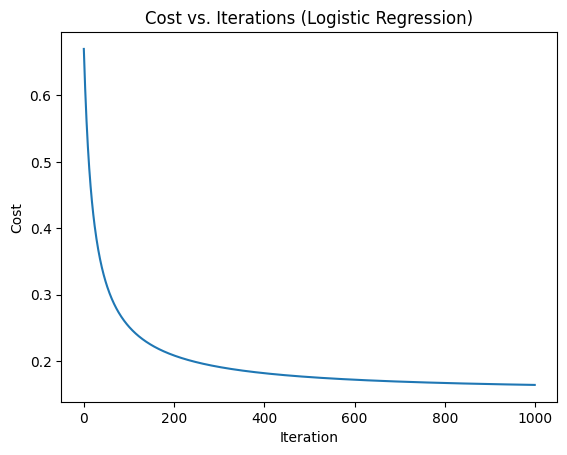

In [ ]:
plt.plot(J_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (Logistic Regression)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

w_check = np.zeros(X_train.shape[1])
b_check = 0.0
w_check, b_check, _ = gradient_descent(X_train, y_train, w_check, b_check, alpha=0.1, num_iters=1000)

def predict_class(X, w, b):
    probs = sigmoid(X @ w + b)
    return (probs >= 0.5).astype(int)

train_acc = np.mean(predict_class(X_train, w_check, b_check) == y_train)
test_acc = np.mean(predict_class(X_test, w_check, b_check) == y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Iteration    0: Cost 0.6694377445166044
Iteration  100: Cost 0.25311699303730273
Iteration  200: Cost 0.21177935674881737
Iteration  300: Cost 0.19566181007994787
Iteration  400: Cost 0.1870969199117715
Iteration  500: Cost 0.1818364634679139
Iteration  600: Cost 0.17832130381608433
Iteration  700: Cost 0.17583899292192195
Iteration  800: Cost 0.1740163541836856
Iteration  900: Cost 0.172638727526711
Train accuracy: 0.9230769230769231
Test accuracy: 0.9473684210526315


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

sklearn_model = LogisticRegression()
sklearn_model.fit(X_scaled, y)

print("Your weights:", w)
print("Sklearn weights:", sklearn_model.coef_[0])
print()
print("Your bias:", b)
print("Sklearn bias:", sklearn_model.intercept_[0])
print()

sklearn_preds = sklearn_model.predict(X_scaled)
your_preds = predict_class(X_scaled, w, b)
print("Sklearn accuracy:", accuracy_score(y, sklearn_preds))
print("Your accuracy:", accuracy_score(y, your_preds))

Your weights: [-3.63871776 -1.29436525 -1.21191093 -0.67563563]
Sklearn weights: [-3.90352994 -1.35781289 -1.30845206 -0.66849643]

Your bias: 0.8528811277160858
Sklearn bias: 0.8855773083745743

Sklearn accuracy: 0.929701230228471
Your accuracy: 0.929701230228471


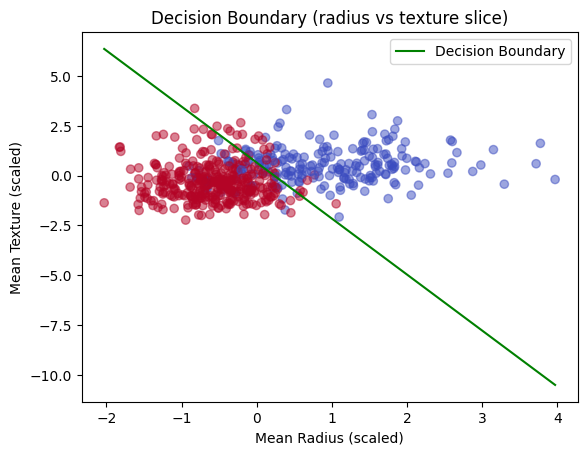

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', alpha=0.5)
plt.xlabel('Mean Radius (scaled)')
plt.ylabel('Mean Texture (scaled)')
plt.title('Decision Boundary (radius vs texture slice)')

x0_vals = np.array([X_scaled[:, 0].min(), X_scaled[:, 0].max()])
x1_vals = -(w[0] * x0_vals + b) / w[1]
plt.plot(x0_vals, x1_vals, 'g-', label='Decision Boundary')
plt.legend()
plt.show()